In [1]:
import sys
from pathlib import Path

import seaborn as sns
import pyro.distributions as dist

import torch
import pyro

rootDir = Path().resolve().parents[0]
sys.path.append(str(rootDir))

from rethinking import MAP, coef, extract_samples, link, precis, sim, vcov

if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    device = torch.device("mps")
    print("Using MPS GPU")
else:
    device = torch.devicce("cpu")
    print("Using CPU")

    

Using MPS GPU


/Users/trevorwilliams/github/SRBayesianPyro/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 4.1 Why normal distributions are normal

Gives example of 1000 people standing on soccer field midline and flipping a coin to step left or right. After the 16 flips, the distance to the midline will be normally distributed around 0

### 4.1.1 Normal by addition

To simulate this scenario, we do a thousand simulations of adding 16 steps together where each step is a specified distance between -1 and 1:

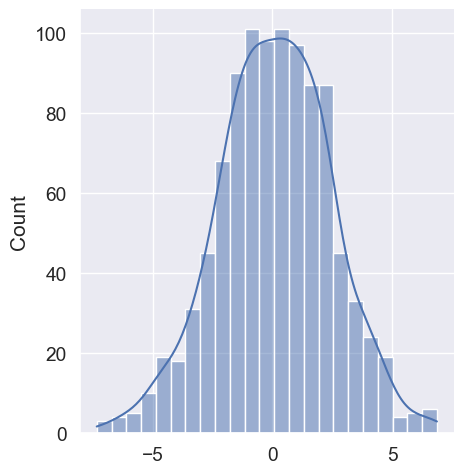

In [22]:
# code 4.1 

pos = torch.empty(1000, 16).uniform_(-1, 1).sum(1)
ax = sns.displot(pos, kde=True)
ax

Any process that adds together random values from the same distribution converges to a normal. Thinking about it in random fluctuations from the average, every positive step gets "cancelled" out by an equal negative step, so the sum converges to 0 (relative to the mean). Doesn't matter what shape the underlying distribution possesses.

### 4.1.2 Normal by Multiplication

Assume growth rate is influenced by a dozen loci, each with several alleles that code for more growth. They all interact to increase growth by a percentage for each loci (i.e. effects multiply). To simulate random growth rate for 12 loci we can run:

In [38]:
# code 4.2

(1 + torch.empty(12).uniform_(0, 0.1)).prod()

tensor(1.5559)

This code samples 12 random numbers between 1.0 and 1.1 each representing a proportional increase in growth - 1 means no growth, 1.1 means 10% increase in growth. Now let's simulate 10000

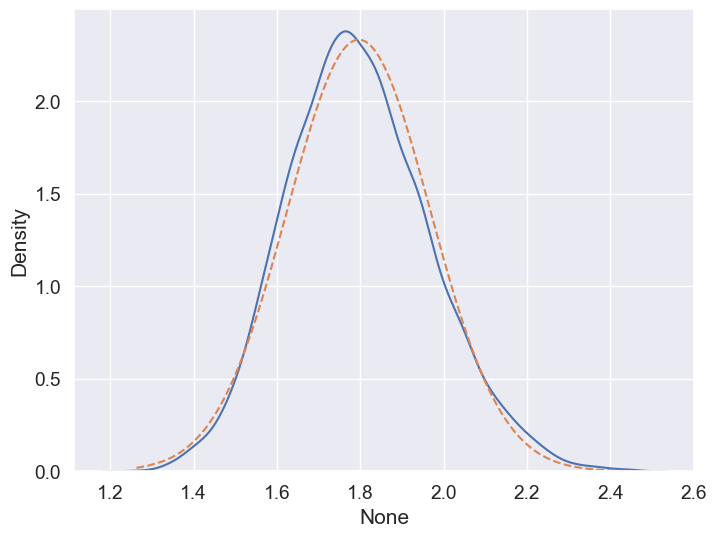

In [60]:
growth = (1 + torch.empty(10000, 12).uniform_(0, 0.1)).prod(1)
sns.kdeplot(growth)
ax = sns.lineplot(x=growth, y=dist.Normal(growth.mean(), growth.std()).log_prob(growth).exp())
ax.lines[1].set_linestyle("--")


We get normal distribution here because the effects are small and multiplying small numbers is approximately the same as addition. For more examples:

[Text(0.5, 1.0, 'small')]

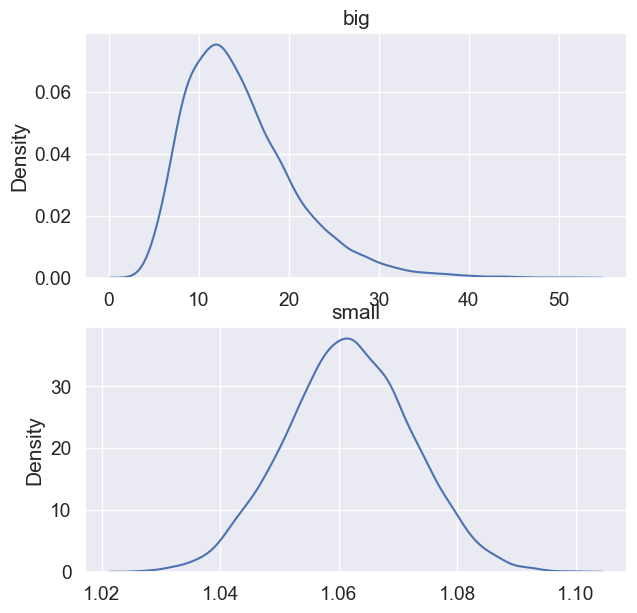

In [ ]:
# code 4.4

import matplotlib.pyplot as plt

big = (1 + torch.empty(10000, 12).uniform_(0, 0.5)).prod(1)
small = (1 + torch.empty(10000, 12).uniform_(0, 0.01)).prod(1)

fig, ax = plt.subplots(2, figsize=(7, 7))

sns.kdeplot(big, ax=ax[0])
ax[0].set(title = "big")
sns.kdeplot(small, ax=ax[1])
ax[1].set(title = "small")




### 4.1.3 Normal by log-multiplication

Large deviates that are multiplied together do not produce Gaussian distributions, but they do tend to produce Gaussian distributions on the log scale, because adding logs is equivalent ot multiplying the original numbers. For example:

<Axes: ylabel='Density'>

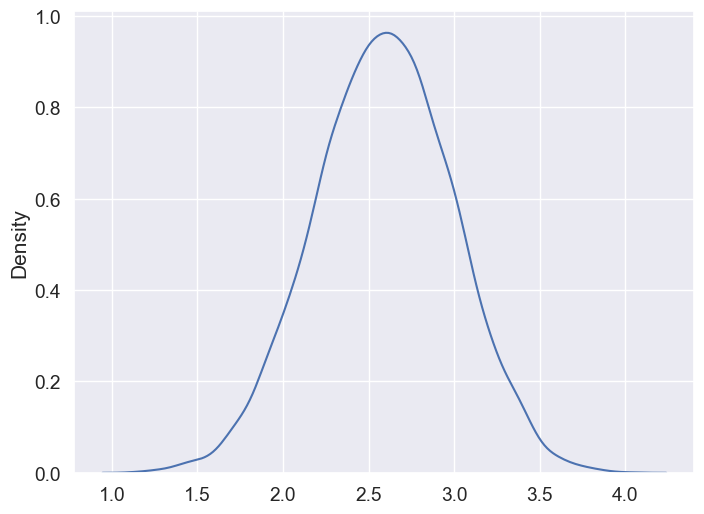

In [ ]:
# code 4.5

log_big = (1 + torch.empty(10000, 12).uniform_(0, 0.5)).prod(1).log()
sns.kdeplot(log_big)

### 4.1.4 Using Gaussian distributions

Jusitification for using the Gaussian distribtuion fall into two broad categories:
 1. Ontological: Gaussian distributions are widespread patterns seen in the world because - many processes repeatedly add finite fluctuations resulting in a distribution of sums that have shed all information about the underlying process aside from the mean and spread. 
     * Consequence: statistical models based on Gaussian distributions cannot reliably identify micro-process
     * Other distributions common in the world - part of fundamental natural distribtuions known as the **EXPONENTIAL FAMILY**
 2. Epistemological: If all we know or are willing to say about a distribution of measures is their mean and variance, then the Gaussian distribution arises as the most consistent with our assumptions.
     * Most natural expression of our state of ignorance
     * Least surprising and least informative assumption to make 
     * Premised on **INFORMATION THEORY** and **MAXIMUM ENTROPY** 

Overthinking: Gaussian Distribution
 * Probability distributions with only discrete outcomes (e.g. binomial) are called *probability mass* functions and denoted with $Pr$.
 * Probability distributions with continuous outcomes (e.g. normal) are called *probability density* functions and denoted $p$
     * Probability densities can be greater than 1 since probability desnity is the rate of change in cumulative probability 
     * Area under the density function will never exceed 1 and are called *probability mass* 

## 4.2 A language for describing models

General recipe of language:
 1. First, we recognize a set of variables to work with.
     * Variables that are observable are called *data*
     * Unobservable variables (like rates and averages) we call *parameters*
 2. We define each variable either in terms of the other variables or in terms of a probability distribution
 3. The combination of variables and ther probability distributions defines a *joint generative model* that can be used both to simulate hypothetical observations as well as analyze real ones.

Once all the decisions are made, we summarize the model with mathematical statements like:

$$ y_{i} \sim \text{Normal}(\mu_{i}, \sigma) $$
$$ \mu_{i} = \beta x_{i} $$
$$ \beta \sim \text{Normal}(0, 10) $$
$$ \sigma \sim \text{Exponential}(1) $$
$$ x_{i} \sim \text{Normal}(0, 1) $$

Provides an unambiguous way to define and communicate models. 

Easy to communicate assumptions of models.

Fundamentally these models define the ways values of some variables can arise, given values of other variables

### Re-describing the glob tossing model

Globe tossing model is:

$$ W \sim \text{Binomial}(N, p) $$
$$ p \sim \text{Uniform}(0, 1) $$

Where $W$ is the observed water count, $N$  is the total number of tosses, and $p$ is the proportion of water on the globe. Read the above statement as: "The count $W$ is distributed binomially with sample size $N$ and probability $p$. The prior for $p$ is assumed to be uniform between zero and one."

In simple models like these, the first line defines the likelihood, the other lines define priors. Both lines in this case are **STOCHASTIC** as indicated by the $\sim$ symbol. 

A stochastic relationship is just a mpaping of a variable or parameter onto a distribution - stochastic since no single instance of the variable on the left is known with certainty.